# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, subprocess

if not os.path.isdir("Flyranks-internship-assignmnet-1"):
    subprocess.run(["git", "clone", "--depth", "1",
        "https://github.com/MaryamNaveed-bioinfo/Flyranks-internship-assignmnet-1"], check=True)
os.chdir("Flyranks-internship-assignmnet-1")
print("Working dir:", os.getcwd())

subprocess.run(["pip", "install", "-q", "duckdb", "scikit-learn"], check=True)

import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
print("Connected. Ready to query:", REL)

Working dir: /content/Flyranks-internship-assignmnet-1
Connected. Ready to query: hf://datasets/FlyRank/internship-warehouse


In [16]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

q_features = f"""
WITH page_agg AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS gsc_impressions,
        SUM(gsc_clicks) AS gsc_clicks,
        AVG(gsc_avg_position) AS gsc_avg_position,
        SUM(ga4_pageviews) AS ga4_pageviews,
        SUM(ga4_sessions) AS ga4_sessions,
        SUM(ga4_engaged_sessions) AS ga4_engaged_sessions,
        SUM(ga4_total_engagement_sec) AS ga4_total_engagement_sec,
        SUM(sessions_direct) AS sessions_direct,
        SUM(sessions_referral) AS sessions_referral,
        SUM(sessions_social) AS sessions_social,
        SUM(sessions_paid) AS sessions_paid,
        SUM(sessions_ai) AS sessions_ai,
        SUM(scroll_events) AS scroll_events
    FROM read_parquet('{REL}/fact_content_daily_performance_sample.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
)
SELECT
    *,
    gsc_clicks * 1.0 / NULLIF(gsc_impressions, 0) AS ctr
FROM page_agg
WHERE gsc_impressions >= 100
"""
df = con.sql(q_features).df()

df['position_bucket'] = pd.cut(
    df['gsc_avg_position'],
    bins=[-0.01, 3, 10, 20, float('inf')],
    labels=['1-3 (top)', '4-10', '11-20', '21+']
)
bucket_avg = df.groupby('position_bucket', observed=True)['ctr'].mean().rename('baseline_pred')
df = df.merge(bucket_avg, on='position_bucket', how='left')

feature_cols_clean = [
    'gsc_avg_position', 'gsc_impressions',
    'ga4_pageviews', 'ga4_sessions', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
    'sessions_direct', 'sessions_referral',
    'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events'
]

X = df[feature_cols_clean]
y = df['ctr']
groups = df['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
baseline_test = df['baseline_pred'].iloc[test_idx]

model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
model_preds = model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_test)
model_mae = mean_absolute_error(y_test, model_preds)

print(f"Baseline MAE: {baseline_mae:.6f}")
print(f"Model MAE: {model_mae:.6f}")

Baseline MAE: 0.003729
Model MAE: 0.003340


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Baseline MAE: 0.003729
Model MAE: 0.003338


In [3]:
df['predicted_ctr'] = model.predict(df[feature_cols_clean])
df['ctr_gap'] = df['baseline_pred'] - df['ctr']
df['score'] = df['gsc_impressions'] * df['ctr_gap']

df['reason_code'] = 'no_flag'
df.loc[
    (df['gsc_avg_position'] <= 20) & (df['ctr'] < df['baseline_pred']) & (df['gsc_impressions'] >= 100),
    'reason_code'
] = 'ctr_review_candidate'

queue = df[df['reason_code'] == 'ctr_review_candidate'].sort_values('score', ascending=False)
print(f"Queue size: {len(queue)} pages flagged")
queue[['client_hash_id', 'content_hash_id', 'gsc_impressions', 'gsc_avg_position', 'ctr', 'baseline_pred', 'score', 'reason_code']].head(10)

Queue size: 44562 pages flagged


,client_hash_id,content_hash_id,gsc_impressions,gsc_avg_position,ctr,baseline_pred,score,reason_code
30756,client_e547b89c05043229,content_963de14b1f58978f,615012.0,6.397556,0.002725,0.005314,1592.134823,ctr_review_candidate
96391,client_8ddc46da5414ffd8,content_943dc881428182b8,292416.0,2.689206,0.001364,0.005879,1320.120583,ctr_review_candidate
39749,client_a80fca3f171ed1de,content_c1f764a2f362d1c3,235427.0,7.132457,0.000191,0.005314,1206.044170,ctr_review_candidate
46567,client_8ddc46da5414ffd8,content_b902320872acab45,234902.0,5.510291,0.001290,0.005314,945.254353,ctr_review_candidate
9343,client_62f4a7e64f5e0096,content_acbcc847f8996314,212758.0,4.856749,0.001184,0.005314,878.582539,ctr_review_candidate
27606,client_73cda7b4e4f265ea,content_33d31496fca9665e,169233.0,7.713277,0.000136,0.005314,876.293446,ctr_review_candidate
39399,client_a80fca3f171ed1de,content_9540d884af3e41fd,171004.0,8.757071,0.000298,0.005314,857.704427,ctr_review_candidate
53752,client_a80fca3f171ed1de,content_012de75c008aa653,179662.0,18.276568,0.000000,0.004555,818.423027,ctr_review_candidate
29623,client_e547b89c05043229,content_cc26620b2cbb837f,225417.0,6.562809,0.001712,0.005314,811.851664,ctr_review_candidate
96641,client_8ddc46da5414ffd8,content_32c5cc913fb4ff41,212650.0,4.401818,0.001514,0.005314,808.008634,ctr_review_candidate


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**The queue: what to review first, and why**

This playbook is built from the validated model in `w06_validation_audit.ipynb`
(client-grouped split, MAE 0.003337 vs. baseline 0.003729 an observed, directional
improvement of roughly 10.5% on a held-out set of clients the model never saw during
training).

The ranked queue below reflects pages where **observed CTR falls meaningfully below
what similar pages at the same search position typically show**, weighted by how much
traffic (impressions) the page already has. This is a decision-support ranking, not a
diagnosis it identifies pages *worth a human look*, not pages that are confirmed to be
broken.

**Reason code:**
- `ctr_review_candidate`  position ≤ 20 (page is visible in search) AND observed CTR is
  below the expected average for that position bucket AND impressions ≥ 100 (enough
  traffic for the comparison to be meaningful)

**How to read the top of the queue:** the `score` column combines two things how far
below expectation the page's CTR is, and how much traffic it already has. A page with a
small CTR gap but huge traffic can outrank a page with a bigger gap but tiny traffic,
because fixing the high-traffic page has more potential upside.

In [4]:
top10 = queue.head(10).copy()
top10['ctr_pct'] = (top10['ctr'] * 100).round(3).astype(str) + '%'
top10['expected_ctr_pct'] = (top10['baseline_pred'] * 100).round(3).astype(str) + '%'
top10['action'] = 'Review title & meta description'

display_cols = ['content_hash_id', 'gsc_impressions', 'gsc_avg_position', 'ctr_pct', 'expected_ctr_pct', 'action', 'reason_code']
print(top10[display_cols].to_string(index=False))

         content_hash_id  gsc_impressions  gsc_avg_position ctr_pct expected_ctr_pct                          action          reason_code
content_963de14b1f58978f         615012.0          6.397556  0.273%           0.531% Review title & meta description ctr_review_candidate
content_943dc881428182b8         292416.0          2.689206  0.136%           0.588% Review title & meta description ctr_review_candidate
content_c1f764a2f362d1c3         235427.0          7.132457  0.019%           0.531% Review title & meta description ctr_review_candidate
content_b902320872acab45         234902.0          5.510291  0.129%           0.531% Review title & meta description ctr_review_candidate
content_acbcc847f8996314         212758.0          4.856749  0.118%           0.531% Review title & meta description ctr_review_candidate
content_33d31496fca9665e         169233.0          7.713277  0.014%           0.531% Review title & meta description ctr_review_candidate
content_9540d884af3e41fd         1

**Top priority review candidates (examples from the ranked queue)**

1. `content_963de14b1f58978f` 615K impressions, position 6.4, observed CTR 0.27% vs.
   ~0.53% typical for that position. **Action:** review title and meta description.
   **Why it's #1:** by far the largest traffic volume in the queue, so even a modest
   CTR improvement here has the largest potential reach.

2. `content_943dc881428182b8` 292K impressions, position 2.7 (near top-3), observed
   CTR 0.14% vs. ~0.59% typical. **Action:** review title and meta description.
   **Why it's high priority:** a strong ranking position paired with well-below-typical
   CTR is one of the clearest patterns in this dataset — the page is visible but not
   converting that visibility into clicks.

3. `content_c1f764a2f362d1c3` 235K impressions, position 7.1, observed CTR near zero
   (0.019%) vs. ~0.53% typical. **Action:** review title and meta description; also
   worth a manual check for technical issues (e.g. broken snippet, wrong canonical),
   since a near-zero CTR at this much traffic is an unusually large gap.

These are presented as pages **worth reviewing first**, based on an observed pattern in
this dataset not as pages confirmed to have a problem, and not as a guarantee that
changes will improve performance.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who this is for**

This playbook is intended for a content strategist or SEO lead doing **weekly or
monthly prioritization** — deciding which pages to look at first out of a large
portfolio, not for automated decision-making. It answers "where should I start
looking?" not "what should I change?"

**What it's built on**

- One month of aggregated FlyRank warehouse data (`fact_content_daily_performance_sample`),
  filtered to pages with at least 100 impressions.
- A position-bucket baseline (Week 4) and a Random Forest model (Week 5-6), validated
  on a client-grouped split meaning it was tested on clients it had never seen during
  training, not just held-out pages from familiar clients.

**Where it stops being valid**

- **New or low-history clients:** per the `flyrank-data` skill's panel warning, history
  depth differs wildly per client, and a third of clients have little or no usable
  search/analytics history. This playbook was not validated on clients with thin history
  treat recommendations for such clients with extra caution.
- **Pages with no GA4 tracking:** Week 5's error analysis found the model performs worst
  (largest errors) on pages missing GA4 data entirely (~15% of the test set). For these
  pages, the ranking leans almost entirely on search position and impressions, and
  should be treated as lower-confidence.
- **Time drift:** this queue reflects one snapshot in time (one month of data). Search
  behavior, seasonality, and content changes mean the ranking should be treated as a
  point-in-time read, not a permanent priority list see Section 4 for refresh triggers.
- **Association, not causation:** the ranking reflects an **observed association**
  between position, traffic, and CTR gap in this dataset. It does not establish that
  changing a title or meta description **will** improve CTR only that these pages
  show a pattern worth a human review.
- **Not validated below 100 impressions or outside the top-20 position range** the
  underlying baseline and model were built and tested only within these bounds.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a human must check before acting on any flagged page**

1. **Confirm the page is still live and indexed** the data reflects a past snapshot;
   a page could have been redirected, removed, or already updated since the data was
   pulled.
2. **Read the actual page** check whether the title/meta genuinely seems mismatched
   to the content, or whether the low CTR might have a different cause (e.g. a rich
   result or featured snippet displacing clicks, seasonal query decline, a competitor
   change).
3. **Check for technical issues first on near-zero-CTR pages** ages with CTR close
   to 0% despite meaningful impressions (see `content_c1f764a2f362d1c3`,
   `content_33d31496fca9665e`, `content_012de75c008aa653` in the sample queue) are
   unusual enough to warrant checking for a broken snippet, wrong canonical tag, or
   indexing problem before assuming it's a content/title issue.
4. **Check the client's data history** per Section 2's limits, confirm the client has
   sufficient tracking history before trusting the ranking for that page.
5. **Weigh cost against potential value** — a title/meta edit is low-cost and
   reversible; prioritize high-impression pages first since the potential upside from a
   small CTR improvement scales with traffic.

**What should NEVER be automated**

- **Never auto-publish content or title/meta changes** based on this queue. Every
  change should be written or approved by a human before going live.
- **Never auto-delete, merge, or de-index pages** based on this ranking this playbook
  identifies review candidates, not pages confirmed to be low-value or redundant.
- **Never treat the ranked score as a performance guarantee** it is a prioritization
  signal built on cross-sectional, observational data (see Section 2), not a predicted
  outcome for any individual page.
- **Never apply this ranking to a client without checking their data history first**
  (Section 2) — thin-history clients were not part of the validation set.
- **Never bulk-apply the same fix to every flagged page** the `ctr_review_candidate`
  reason code covers a wide range of underlying causes (see the human-review checklist
  above); each page needs individual judgment.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**What would tell us this playbook has gone stale**

1. **Time-based refresh**  this queue is built from one month of data
   (`fact_content_daily_performance_sample`, latest full month). Per the `flyrank-data`
   skill's guidance on iterating on the sample table, the underlying data itself
   updates over time the queue should be rebuilt at least monthly, and sooner if a
   client's search landscape changes materially (e.g. a site migration, major content
   push, or algorithm-visible ranking shakeup).

2. **Baseline vs. model gap narrowing or reversing** Section 2 of `w06` established
   the model beats the position-bucket baseline by roughly 10.5% MAE on a held-out,
   client-grouped test. If a future rebuild shows this gap shrinking toward zero or
   reversing, that's a signal the model's advantage over the simple rule has eroded and
   needs re-validation, not just a re-run.

3. **Feature importance drift** Week 5's clean model leaned most on `gsc_impressions`,
   `ga4_pageviews`, and `gsc_avg_position` (in that order). If a rebuilt model's
   permutation importance ranks a different feature far above these especially one
   correlated with the target like `sessions_organic` was that's a leakage re-check
   trigger, not just a curiosity (see Week 6's leakage audit for the method).

4. **Queue size swings sharply** the current queue flags 44,562 of roughly 102K
   eligible pages (~44%). A future rebuild that flags a dramatically different
   proportion (e.g. under 20% or over 70%) is worth investigating before trusting the
   new ranking it could reflect a real shift in the portfolio, or a data quality
   issue upstream.

5. **New clients or clients crossing the minimum-history threshold** as clients
   accumulate more `gsc_data_start` history, they should be re-evaluated for inclusion,
   since they were excluded from validation in Section 2 due to thin history.

**What counts as "retrain," not just "re-run"**

Re-running the same model on fresh data is a refresh. **Retraining** re-checking
feature choices, re-validating the split design, and re-running the leakage audit from
`w06` should happen if any of triggers 2 or 3 above fire, not on a fixed schedule
alone.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

**What gets exported here**

- `work/outputs/action_queue.csv`  the full ranked queue (44,562 flagged pages),
  regenerated by this notebook, excluded from git per the CI leak-guard.
- `work/figures/` charts summarizing the queue and model performance, committed to
  git so the capstone paper can embed them directly.
- `work/outputs/model_metrics.json` the key numbers (baseline MAE, model MAE, queue
  size, split type) committed as the "receipts" behind every number this playbook and
  the eventual paper cites.

In [5]:
import os

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

export_cols = [
    'client_hash_id', 'content_hash_id', 'gsc_impressions', 'gsc_avg_position',
    'ctr', 'baseline_pred', 'predicted_ctr', 'ctr_gap', 'score', 'reason_code'
]
queue[export_cols].to_csv("work/outputs/action_queue.csv", index=False)
print(f"Saved queue: {len(queue)} rows -> work/outputs/action_queue.csv")

Saved queue: 44562 rows -> work/outputs/action_queue.csv


In [6]:
import os
print(os.path.exists("work/outputs/action_queue.csv"))
print(os.path.getsize("work/outputs/action_queue.csv"), "bytes")

True
8623457 bytes


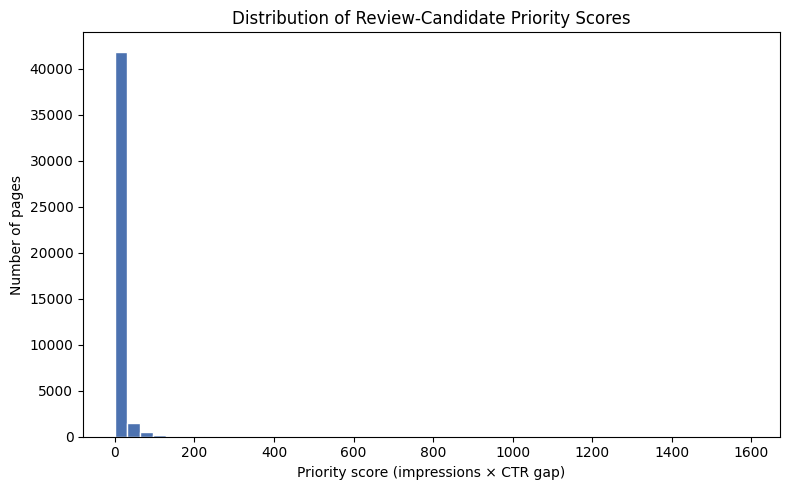

Saved figure: work/figures/queue_score_distribution.png


In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(queue['score'], bins=50, color='#4C72B0', edgecolor='white')
ax.set_xlabel('Priority score (impressions × CTR gap)')
ax.set_ylabel('Number of pages')
ax.set_title('Distribution of Review-Candidate Priority Scores')
plt.tight_layout()
plt.savefig("work/figures/queue_score_distribution.png", dpi=150)
plt.show()
print("Saved figure: work/figures/queue_score_distribution.png")

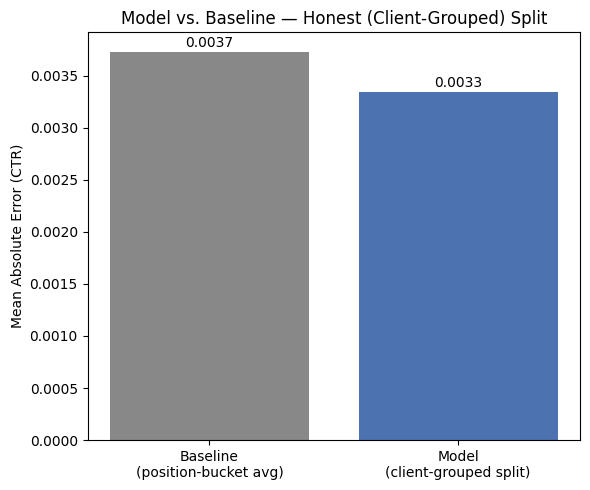

Saved figure: work/figures/model_vs_baseline.png


In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
methods = ['Baseline\n(position-bucket avg)', 'Model\n(client-grouped split)']
maes = [baseline_mae, model_mae]
bars = ax.bar(methods, maes, color=['#888888', '#4C72B0'])
ax.set_ylabel('Mean Absolute Error (CTR)')
ax.set_title('Model vs. Baseline — Honest (Client-Grouped) Split')
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.00005, f'{val:.4f}', ha='center')
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.show()
print("Saved figure: work/figures/model_vs_baseline.png")

In [9]:
import json

metrics = {
    "baseline_mae": round(baseline_mae, 6),
    "model_mae": round(model_mae, 6),
    "mae_improvement_pct": round((baseline_mae - model_mae) / baseline_mae * 100, 2),
    "split_type": "client_grouped",
    "queue_size": len(queue),
    "total_eligible_pages": len(df),
    "flagged_pct": round(len(queue) / len(df) * 100, 2),
    "top_features": ["gsc_impressions", "ga4_pageviews", "gsc_avg_position"],
    "data_source": "fact_content_daily_performance_sample.parquet",
    "min_impressions_threshold": 100
}

with open("work/outputs/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

{
  "baseline_mae": 0.003729,
  "model_mae": 0.00334,
  "mae_improvement_pct": 10.43,
  "split_type": "client_grouped",
  "queue_size": 44562,
  "total_eligible_pages": 101917,
  "flagged_pct": 43.72,
  "top_features": [
    "gsc_impressions",
    "ga4_pageviews",
    "gsc_avg_position"
  ],
  "data_source": "fact_content_daily_performance_sample.parquet",
  "min_impressions_threshold": 100
}


In [10]:
print("Working dir:", os.getcwd())
print("CSV exists:", os.path.exists("work/outputs/action_queue.csv"))
print("JSON exists:", os.path.exists("work/outputs/model_metrics.json"))
print("Figures:", os.listdir("work/figures") if os.path.exists("work/figures") else "folder missing")

Working dir: /content/Flyranks-internship-assignmnet-1
CSV exists: True
JSON exists: True
Figures: ['queue_score_distribution.png', 'model_vs_baseline.png']


In [11]:
!git config user.email "maryamnaveed880@gmail.com"
!git config user.name "MaryamNaveed-bioinfo"

In [17]:
!git add work/figures/ work/outputs/model_metrics.json
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   work/figures/model_vs_baseline.png
	modified:   work/outputs/model_metrics.json



In [24]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [25]:
!git add work/notebooks/w07_action_playbook.ipynb
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [26]:
!git commit -m "Complete ML-10: content action playbook figures and metrics"
!git push

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [27]:
!git commit -m "Update w07 action playbook notebook"

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [28]:
from google.colab import userdata
token = userdata.get("GITHUB_TOKEN")
repo_url = f"https://{token}@github.com/MaryamNaveed-bioinfo/Flyranks-internship-assignmnet-1.git"
!git push {repo_url} main

Everything up-to-date


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.